# Задание III. Кластеризация — вариант 4

Пропуски: `KnnImputer(neighbors=5)`; шкалы: `MaxAbsScaler`; иерархическая кластеризация:
`link=average, dist=euclidean`; проекция: PCA; кластеры с прототипом: KMeans; VarClus: 5 переменных.

In [ ]:
%pip install -q varclushi

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score
from varclushi import VarClusHi

## 1. Загрузка данных

In [3]:
df = pd.read_csv('baseball.csv').set_index('Name')   # Name — идентификатор записи

CAT = ['Team', 'Position', 'League', 'Division', 'Div']   # NOMINAL
NUM = [c for c in df.columns if c not in CAT]              # INTERVAL
df.head()

,Team,nAtBat,nHits,nHome,nRuns,nRBI,nBB,YrMajor,CrAtBat,CrHits,...,CrBB,League,Division,Position,nOuts,nAssts,nError,Salary,Div,logSalary
Name,,,,,,,,,,,,,,,,,,,,,
"Allanson, Andy",Cleveland,293,66,1,30,29,14,1,293,66,...,14,American,East,C,446,33,20,NaN,AE,NaN
"Ashby, Alan",Houston,315,81,7,24,38,39,14,3449,835,...,375,National,West,C,632,43,10,475.0,NW,6.163315
"Davis, Alan",Seattle,479,130,18,66,72,76,3,1624,457,...,263,American,West,1B,880,82,14,480.0,AW,6.173786
"Dawson, Andre",Montreal,496,141,20,65,78,37,11,5628,1575,...,354,National,East,RF,200,11,3,500.0,NE,6.214608
"Galarraga, Andres",Montreal,321,87,10,39,42,30,2,396,101,...,33,National,East,1B,805,40,4,91.5,NE,4.516339


## 2. Обработка пропусков: KNNImputer(n_neighbors=5)

In [4]:
df.isna().sum()[lambda s: s > 0]

Salary       59
logSalary    59
dtype: int64

In [5]:
df[NUM] = KNNImputer(n_neighbors=5).fit_transform(df[NUM])
df['logSalary'] = np.log1p(df['Salary'])
df.isna().sum().sum()

np.int64(0)

## 3. Нормализация: MaxAbsScaler + OneHotEncoder

In [6]:
def prepare(data, num_cols, cat_cols):
    X = pd.DataFrame(MaxAbsScaler().fit_transform(data[num_cols]), index=data.index, columns=num_cols)
    if cat_cols:
        ohe = OneHotEncoder(sparse_output=False)
        X = X.join(pd.DataFrame(ohe.fit_transform(data[cat_cols]), index=data.index,
                                columns=ohe.get_feature_names_out(cat_cols)))
    return X

X = prepare(df, NUM, CAT)
X.head()

,nAtBat,nHits,nHome,nRuns,nRBI,nBB,YrMajor,CrAtBat,CrHits,CrHome,...,Position_SS,Position_UT,League_American,League_National,Division_East,Division_West,Div_AE,Div_AW,Div_NE,Div_NW
Name,,,,,,,,,,,,,,,,,,,,,
"Allanson, Andy",0.426492,0.277311,0.025,0.230769,0.239669,0.133333,0.041667,0.020850,0.015508,0.001825,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
"Ashby, Alan",0.458515,0.340336,0.175,0.184615,0.314050,0.371429,0.583333,0.245428,0.196194,0.125912,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
"Davis, Alan",0.697234,0.546218,0.450,0.507692,0.595041,0.723810,0.125000,0.115563,0.107378,0.114964,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
"Dawson, Andre",0.721980,0.592437,0.500,0.500000,0.644628,0.352381,0.458333,0.400484,0.370066,0.410584,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
"Galarraga, Andres",0.467249,0.365546,0.250,0.300000,0.347107,0.285714,0.083333,0.028179,0.023731,0.021898,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


## 4. Иерархическая кластеризация (average, euclidean) и дендрограмма для топ-20 кластеров

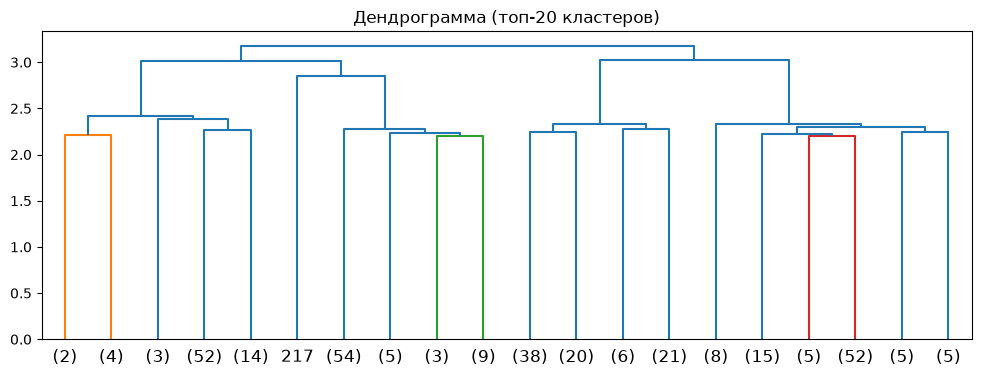

In [7]:
def plot_dendrogram(Z):
    plt.figure(figsize=(12, 4))
    dendrogram(Z, truncate_mode='lastp', p=20)
    plt.title('Дендрограмма (топ-20 кластеров)')
    plt.show()

Z = linkage(X, method='average', metric='euclidean')
plot_dendrogram(Z)

## 5. pseudoF для 2–20 кластеров

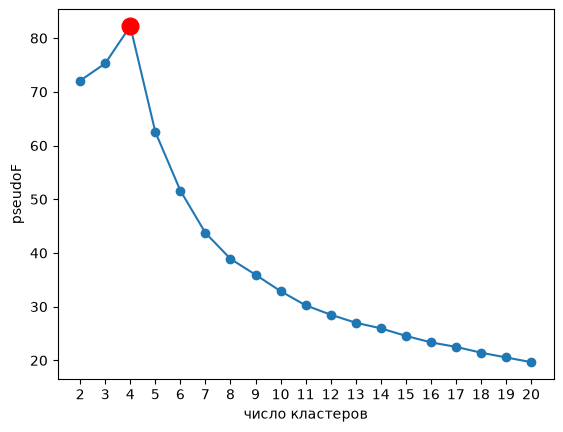

Число кластеров: 4


In [8]:
def pseudo_f(X, Z):
    # pseudoF = статистика Калински-Харабаша
    return pd.Series({k: calinski_harabasz_score(X, fcluster(Z, k, criterion='maxclust'))
                      for k in range(2, 21)})

def first_local_peak(f):
    for k in f.index[1:-1]:
        if f[k] > f[k - 1] and f[k] > f[k + 1]:
            return k
    return f.idxmax()

def plot_pseudo_f(f, k):
    plt.plot(f.index, f.values, marker='o')
    plt.plot(k, f[k], 'ro', markersize=12)
    plt.xticks(f.index)
    plt.xlabel('число кластеров')
    plt.ylabel('pseudoF')
    plt.show()

f = pseudo_f(X, Z)
k = first_local_peak(f)
plot_pseudo_f(f, k)
print('Число кластеров:', k)

## 6. Проекция на плоскость: PCA

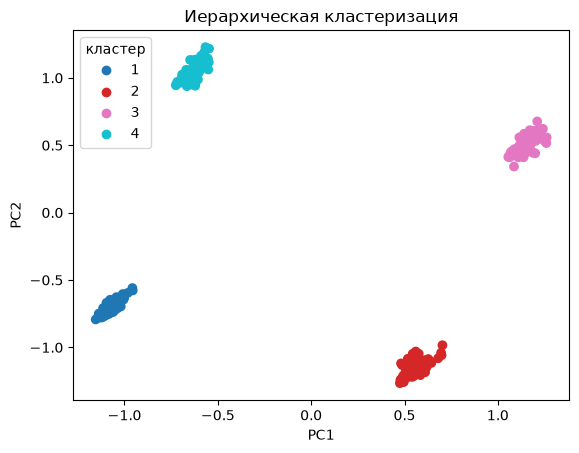

In [9]:
def plot_projection(P, labels, title):
    sc = plt.scatter(P[:, 0], P[:, 1], c=labels, cmap='tab10')
    plt.legend(*sc.legend_elements(), title='кластер')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(title)
    plt.show()

P = PCA(n_components=2).fit_transform(X)
hier_labels = fcluster(Z, k, criterion='maxclust')
plot_projection(P, hier_labels, 'Иерархическая кластеризация')

## 7. KMeans и наиболее типичные представители

Наиболее типичный представитель кластера — игрок, ближайший к центроиду.

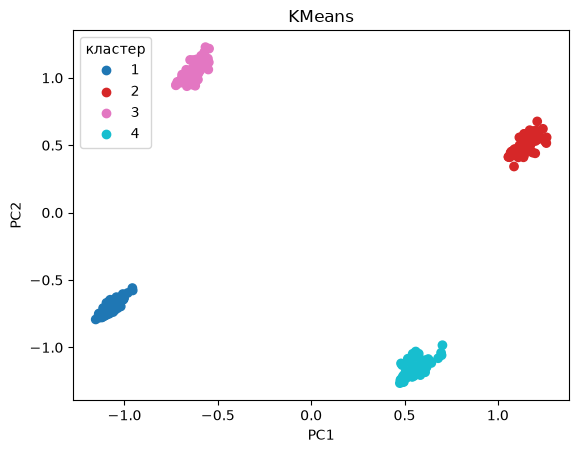

1     Landreaux, Ken
2        Hassey, Ron
3    Henderson, Dave
4     Wilson, Mookie
Name: типичный представитель, dtype: str

In [10]:
def kmeans_typical(X, k):
    km = KMeans(n_clusters=k, random_state=0).fit(X)
    dist = km.transform(X)
    typical = {c + 1: X.index[np.argmin(np.where(km.labels_ == c, dist[:, c], np.inf))] for c in range(k)}
    return km.labels_ + 1, pd.Series(typical, name='типичный представитель')

km_labels, typical = kmeans_typical(X, k)
plot_projection(P, km_labels, 'KMeans')
typical

## 8. Шаги 3–7 в виде функции

In [11]:
def cluster_analysis(data, num_cols, cat_cols):
    X = prepare(data, num_cols, cat_cols)                 # 3
    Z = linkage(X, method='average', metric='euclidean')  # 4
    plot_dendrogram(Z)
    f = pseudo_f(X, Z)                                    # 5
    k = first_local_peak(f)
    plot_pseudo_f(f, k)
    print('Число кластеров:', k)
    P = PCA(n_components=2).fit_transform(X)              # 6
    plot_projection(P, fcluster(Z, k, criterion='maxclust'), 'Иерархическая кластеризация')
    km_labels, typical = kmeans_typical(X, k)             # 7
    plot_projection(P, km_labels, 'KMeans')
    return typical

## 9. Преобразование log(1+x) для переменных с тяжёлым правым хвостом

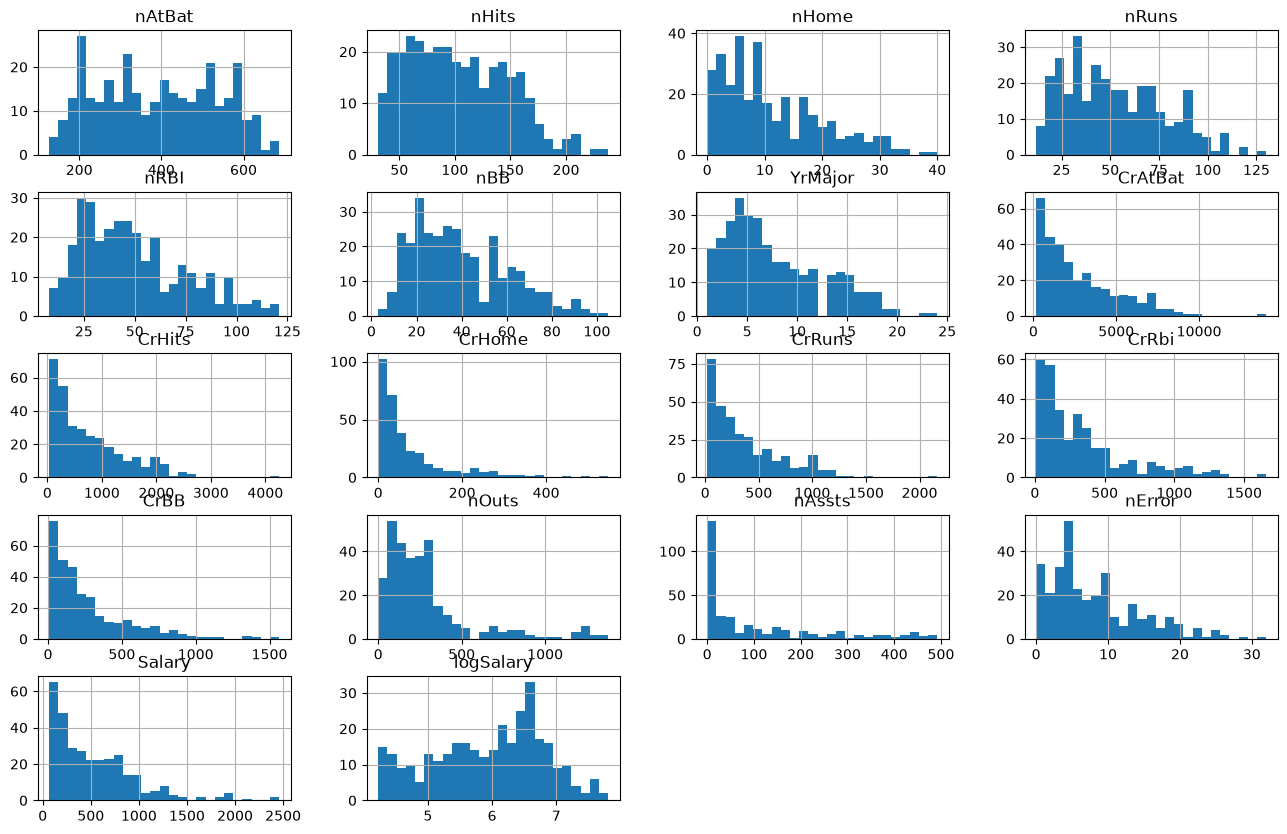

CrHome       2.135479
nOuts        2.065057
CrBB         1.733534
Salary       1.539081
CrRbi        1.459407
nAssts       1.358483
CrRuns       1.352553
CrHits       1.295944
CrAtBat      1.164102
nError       1.055453
nHome        0.919207
YrMajor      0.716007
nRBI         0.704760
nBB          0.689484
nRuns        0.509917
nHits        0.423384
nAtBat       0.075986
logSalary   -0.240514
dtype: float64

In [12]:
df[NUM].hist(bins=25, figsize=(16, 10))
plt.show()
df[NUM].skew().sort_values(ascending=False)

In [13]:
RIGHT = df[NUM].columns[df[NUM].skew() > 1].tolist()   # одна мода и тяжёлый правый хвост
print(RIGHT)
df_log = df.copy()
df_log[RIGHT] = np.log1p(df_log[RIGHT])

['CrAtBat', 'CrHits', 'CrHome', 'CrRuns', 'CrRbi', 'CrBB', 'nOuts', 'nAssts', 'nError', 'Salary']


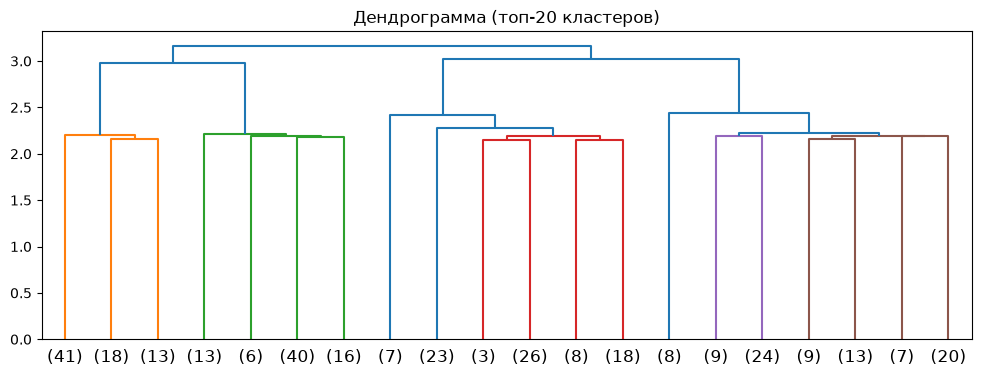

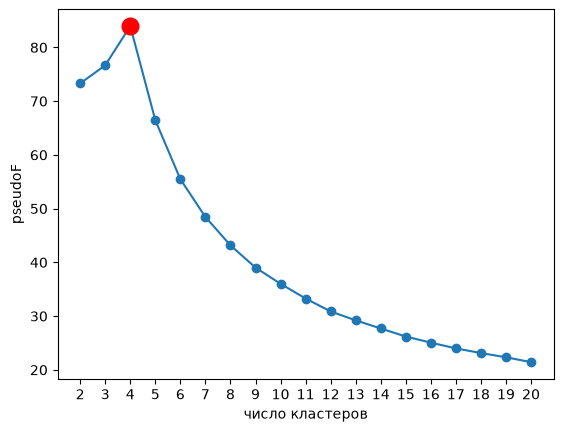

Число кластеров: 4


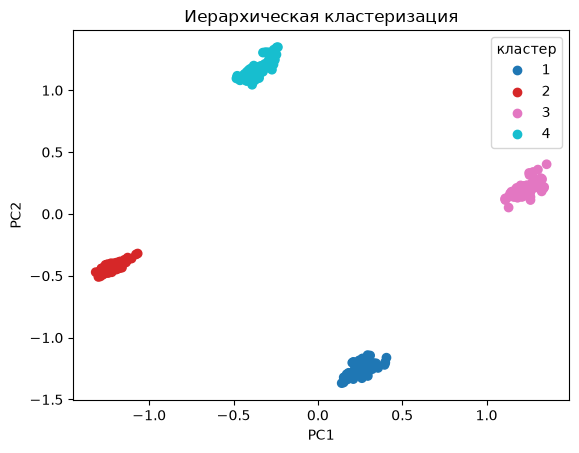

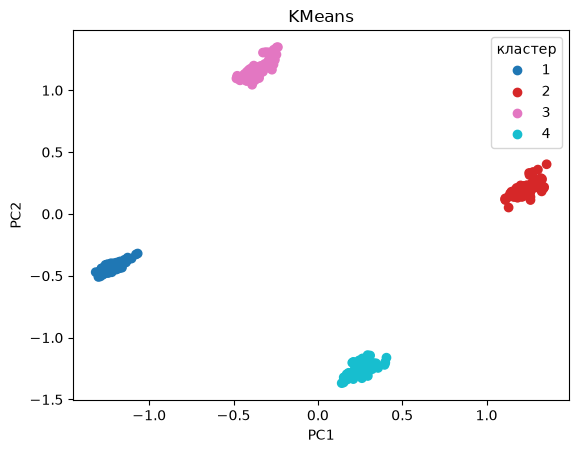

1      Esasky, Nick
2       Hassey, Ron
3      Slaught, Don
4    Wilson, Mookie
Name: типичный представитель, dtype: str

In [14]:
cluster_analysis(df_log, NUM, CAT)

**Ответ.** Число кластеров не изменилось — 4. Проекции практически те же: четыре далеко
разнесённых облака. Лучшие представители частично сменились: Hassey, Ron и Wilson, Mookie
остались, Landreaux, Ken → Esasky, Nick, Henderson, Dave → Slaught, Don.

Субъективное качество не изменилось. Четыре кластера — это четыре дивизиона
(AE, AW, NE, NW), а не группы игроков с похожей игрой. Причина: после MaxAbsScaler
OneHot-признаки имеют ту же шкалу [0, 1], что и числовые, их 57 против 18, а дивизион
закодирован трижды (League, Division, Div), поэтому именно они определяют расстояния.
Логарифм меняет только числовые признаки — он лишь немного сдвинул центры кластеров
(отсюда смена части представителей), но на само разбиение не повлиял.

## 10. Отбор 5 переменных методом VarClus

In [15]:
vc = VarClusHi(df_log[NUM], maxeigval2=0, maxclus=5)
vc.varclus()
vc.rsquare

,Cluster,Variable,RS_Own,RS_NC,RS_Ratio
0,0,YrMajor,0.725715,0.033136,0.283686
1,0,CrAtBat,0.966491,0.113199,0.037786
2,0,CrHits,0.967671,0.129946,0.037158
3,0,CrHome,0.774876,0.349723,0.346198
4,0,CrRuns,0.964987,0.156528,0.041511
5,0,CrRbi,0.966106,0.203642,0.042562
6,0,CrBB,0.913809,0.120325,0.097980
7,0,Salary,0.796209,0.246397,0.270422
8,0,logSalary,0.796209,0.246397,0.270422
9,1,nAtBat,0.923157,0.510544,0.156998


In [16]:
# из каждого кластера переменных — переменная с минимальным RS_Ratio
SELECTED = vc.rsquare.loc[vc.rsquare.groupby('Cluster')['RS_Ratio'].idxmin(), 'Variable'].tolist()
SELECTED

['CrHits', 'nRuns', 'nAssts', 'nOuts', 'nHome']

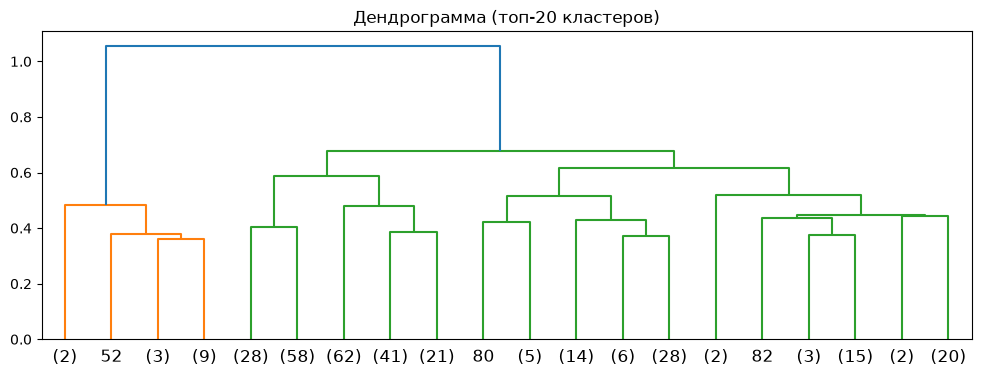

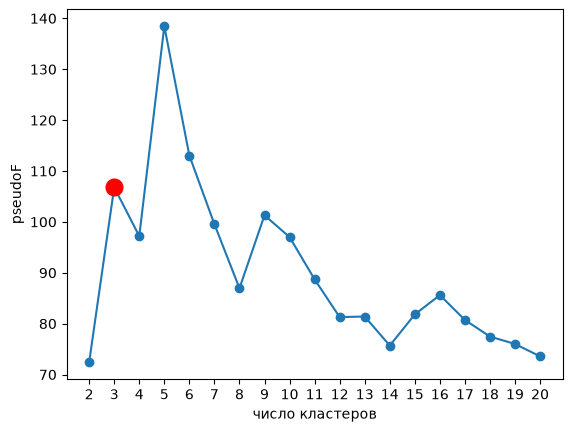

Число кластеров: 3


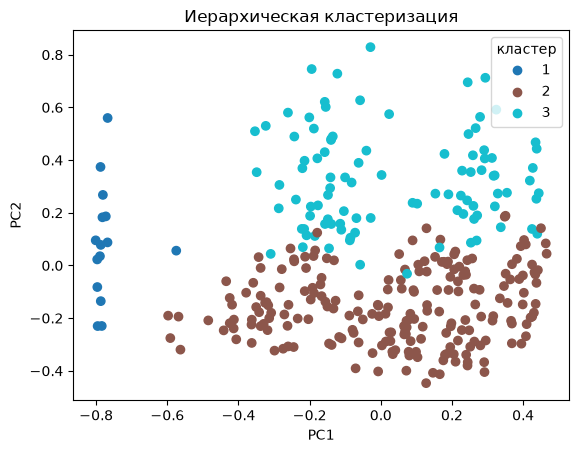

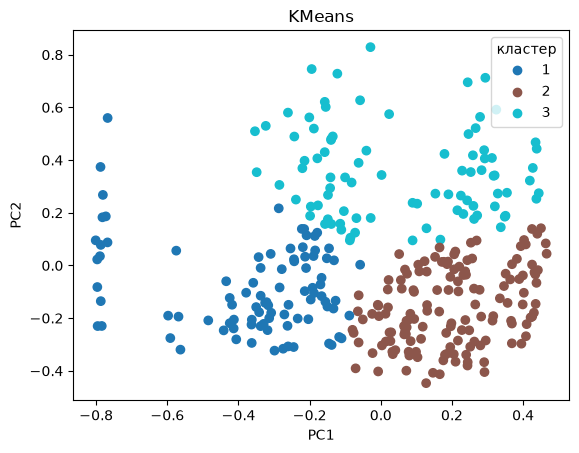

1    Castillo, Carmen
2         Teufel, Tim
3      Baines, Harold
Name: типичный представитель, dtype: str

In [17]:
cluster_analysis(df_log, SELECTED, [])

**Ответ.** VarClus отобрал по одной переменной из 5 групп: CrHits (карьера), nRuns и
nHome (нападение за сезон), nAssts и nOuts (игра в защите). Число кластеров уменьшилось
до 3. Проекция изменилась: вместо четырёх изолированных облаков — одно облако, внутри
которого кластеры граничат друг с другом. Новые лучшие представители: Castillo, Carmen,
Teufel, Tim и Baines, Harold.

Субъективное качество стало лучше: кластеры больше не повторяют дивизионы, а
описывают самих игроков — игроки почти без передач в защите (аутфилдеры и DH), игроки с
большим числом передач (инфилдеры и кэтчеры) и самые результативные отбивающие.
Причина: ушли OneHot-признаки, которые доминировали в расстоянии, а VarClus убрал
дублирующие друг друга сильно коррелированные переменные, оставив по одной из каждой
группы, поэтому все стороны игры входят в расстояние с равным весом.